### TASK-1 : Credit Score Prediction

In [2]:
import pandas as pd
import numpy as np 
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("CreditScore.csv")
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000,Master's Degree,Married,2,Owned,High
2,35,Female,75000,Doctorate,Married,1,Owned,High
3,40,Male,125000,High School Diploma,Single,0,Owned,High
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High


In [4]:
df.tail()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
159,29,Female,27500,High School Diploma,Single,0,Rented,Low
160,34,Male,47500,Associate's Degree,Single,0,Rented,Average
161,39,Female,62500,Bachelor's Degree,Married,2,Owned,High
162,44,Male,87500,Master's Degree,Single,0,Owned,High
163,49,Female,77500,Doctorate,Married,1,Owned,High


In [5]:
df.nunique()

Age                   29
Gender                 2
Income                52
Education              5
Marital Status         2
Number of Children     4
Home Ownership         2
Credit Score           3
dtype: int64

In [6]:
df.dtypes

Age                    int64
Gender                object
Income                 int64
Education             object
Marital Status        object
Number of Children     int64
Home Ownership        object
Credit Score          object
dtype: object

In [7]:
df.info

<bound method DataFrame.info of      Age  Gender  Income            Education Marital Status  \
0     25  Female   50000    Bachelor's Degree         Single   
1     30    Male  100000      Master's Degree        Married   
2     35  Female   75000            Doctorate        Married   
3     40    Male  125000  High School Diploma         Single   
4     45  Female  100000    Bachelor's Degree        Married   
..   ...     ...     ...                  ...            ...   
159   29  Female   27500  High School Diploma         Single   
160   34    Male   47500   Associate's Degree         Single   
161   39  Female   62500    Bachelor's Degree        Married   
162   44    Male   87500      Master's Degree         Single   
163   49  Female   77500            Doctorate        Married   

     Number of Children Home Ownership Credit Score  
0                     0         Rented         High  
1                     2          Owned         High  
2                     1          Owne

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,164.0,37.975610,8.477289,25.0,30.75,37.0,45.0,53.0
Income,164.0,83765.243902,32457.306728,25000.0,57500.00,83750.0,105000.0,162500.0
Number of Children,164.0,0.652439,0.883346,0.0,0.00,0.0,1.0,3.0


In [9]:
df.isna().any()

Age                   False
Gender                False
Income                False
Education             False
Marital Status        False
Number of Children    False
Home Ownership        False
Credit Score          False
dtype: bool

In [10]:
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
cat_cols

['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in cat_cols:
    le.fit(df[i])
    df[i] = le.transform(df[i])

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols   # empty columns 

[]

In [13]:
df.corr()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
Age,1.000000,0.235343,0.699464,0.170254,-0.517723,0.055390,-0.713803,0.205362
Gender,0.235343,1.000000,0.495738,0.248671,0.278362,-0.442139,-0.031519,-0.247729
Income,0.699464,0.495738,1.000000,0.369449,-0.471004,0.084547,-0.704928,0.083698
Education,0.170254,0.248671,0.369449,1.000000,-0.067797,0.047311,-0.397043,0.334424
Marital Status,-0.517723,0.278362,-0.471004,-0.067797,1.000000,-0.696984,0.708374,-0.205756
Number of Children,0.055390,-0.442139,0.084547,0.047311,-0.696984,1.000000,-0.497129,0.136517
Home Ownership,-0.713803,-0.031519,-0.704928,-0.397043,0.708374,-0.497129,1.000000,-0.293384
Credit Score,0.205362,-0.247729,0.083698,0.334424,-0.205756,0.136517,-0.293384,1.000000


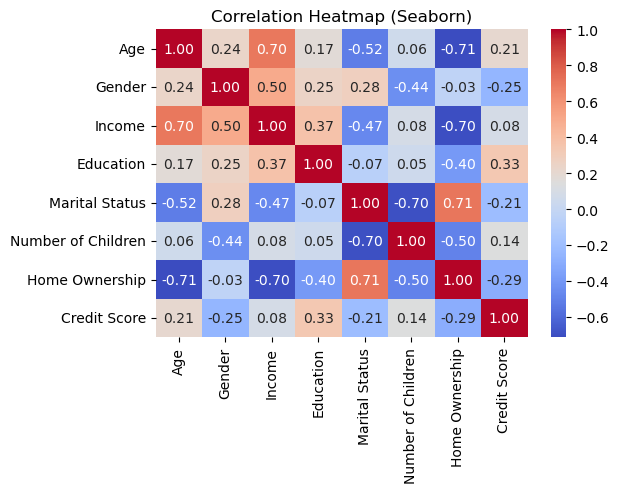

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Seaborn)")
plt.show()

In [15]:
class_counts = df['Credit Score'].value_counts()

# Print the class distribution
print('Class distribution:')
print(class_counts)

Class distribution:
Credit Score
1    113
0     36
2     15
Name: count, dtype: int64


In [16]:
X = df.drop('Credit Score', axis = 1)
y = df['Credit Score']
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
sm = SMOTE(random_state=42)

# Fit SMOTE to training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
# Print class distribution of original and resampled data
print('Class distribution before resampling:', y_train.value_counts())
print('Class distribution after resampling:', y_train_res.value_counts())

Class distribution before resampling: Credit Score
1    90
0    31
2    10
Name: count, dtype: int64
Class distribution after resampling: Credit Score
1    90
0    90
2    90
Name: count, dtype: int64


In [20]:
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,0,50000,1,1,0,1,1
1,30,1,100000,4,0,2,0,1
2,35,0,75000,2,0,1,0,1
3,40,1,125000,3,1,0,0,1
4,45,0,100000,1,0,3,0,1


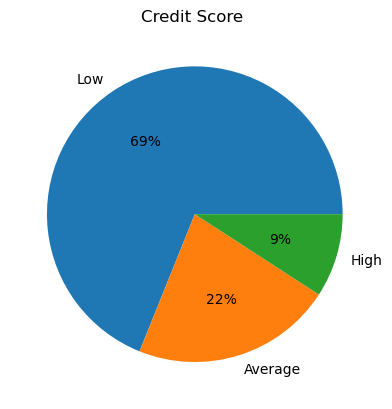

In [19]:
class_counts = df['Credit Score'].value_counts()
labels = ["Low", "Average", "High"]
values = class_counts.values
plt.pie(values, labels=labels, autopct="%1.0f%%")
plt.title("Credit Score ")
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [23]:
#  Train Models
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [24]:
# Predict class labels
y_pred_lr = lr.predict(X_test)          # Logistic Regression 
y_pred_dt = dt.predict(X_test)          # Decision Tree
y_pred_rf = rf.predict(X_test)          # Random Forest

In [28]:

# Logistic Regression
print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# Handle ROC-AUC for binary vs multiclass
if len(np.unique(y_test)) == 2:
    roc_auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
else:
    roc_auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test), multi_class='ovr')
print("ROC-AUC:", roc_auc_lr)

# Decision Tree
print("\nDecision Tree Results")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

if len(np.unique(y_test)) == 2:
    roc_auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])
else:
    roc_auc_dt = roc_auc_score(y_test, dt.predict_proba(X_test), multi_class='ovr')
print("ROC-AUC:", roc_auc_dt)

# Random Forest
print("\nRandom Forest Results")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

if len(np.unique(y_test)) == 2:
    roc_auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
else:
    roc_auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovr')
print("ROC-AUC:", roc_auc_rf)



Logistic Regression Results
              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.96      1.00      0.98        23
           2       1.00      1.00      1.00         5

    accuracy                           0.97        33
   macro avg       0.99      0.93      0.96        33
weighted avg       0.97      0.97      0.97        33

Confusion Matrix:
 [[ 4  1  0]
 [ 0 23  0]
 [ 0  0  5]]
ROC-AUC: 1.0

Decision Tree Results
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.96      0.98        23
           2       1.00      1.00      1.00         5

    accuracy                           0.97        33
   macro avg       0.94      0.99      0.96        33
weighted avg       0.97      0.97      0.97        33

Confusion Matrix:
 [[ 5  0  0]
 [ 1 22  0]
 [ 0  0  5]]
ROC-AUC: 0.9868012422360248

Random Forest Results
           

# Logistic Regression
Accuracy: 97%

Precision/Recall/F1: Very strong across all classes (0, 1, 2)

Confusion Matrix: Only 1 misclassification (class 0 misclassified once)

ROC‑AUC: 1.0 (perfect)  
Performs extremely well, almost flawless separation

# Decision Tree
Accuracy: 97%

Precision/Recall/F1: Also very strong, slightly lower precision for class 0

Confusion Matrix: 1 misclassification (class 1 misclassified once)

ROC‑AUC: 0.987 (excellent, but not perfect)
 Very good, but a tiny bit weaker than Logistic Regression in ROC‑AUC.

# Random Forest
Accuracy: 97%

Precision/Recall/F1: Matches Decision Tree (same confusion matrix)

Confusion Matrix: 1 misclassification (class 1 misclassified once)

ROC‑AUC: 1.0 (perfect)  
 Matches Logistic Regression in ROC‑AUC, slightly stronger than Decision Tree

In [ ]:
#Best performers here are Logistic Regression and Random Forest (both hit ROC‑AUC = 1.0)Decision Tree is strong but just a notch below in ROC‑AUC